In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.datasets import make_classification, make_circles

SEED = 42
np.random.seed(SEED)

csv_path = "../../../data/raw/classification/covtype.csv"

df = pd.read_csv(csv_path)

target_col = "Cover_Type"

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

continuous_cols = X.columns[:10].tolist()
wilderness_cols = [c for c in X.columns if c.startswith("Wilderness_Area")]
soil_cols = [c for c in X.columns if c.startswith("Soil_Type")]
binary_cols = wilderness_cols + soil_cols

In [2]:
X_temp_raw, X_test_raw, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

# Val chiếm 10% tổng dữ liệu -> 12.5% trên tập tạm (80%)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.125,
    random_state=SEED,
    stratify=y_temp,
)

# Preprocessing pipeline

In [3]:
class IQROutlierClipper(BaseEstimator, TransformerMixin):
    """Clip outliers theo IQR cho từng cột continuous, fit trên train để tránh leakage."""

    def __init__(self, whisker_width=1.5):
        self.whisker_width = whisker_width
        self.lower_bounds_ = None
        self.upper_bounds_ = None
        self.columns_ = None

    def fit(self, X, _y=None):
        _ = _y
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        self.columns_ = X.columns.tolist()
        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1
        self.lower_bounds_ = q1 - self.whisker_width * iqr
        self.upper_bounds_ = q3 + self.whisker_width * iqr
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns_)
        return X.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)

In [4]:
def add_engineered_features(X_input: pd.DataFrame) -> pd.DataFrame:
    """Tạo đặc trưng mới từ nhóm khoảng cách địa lý."""
    X_out = X_input.copy()

    # Khoảng cách Euclid đến thủy văn
    X_out["Euclidean_Distance_To_Hydrology"] = np.sqrt(
        X_out["Horizontal_Distance_To_Hydrology"] ** 2
        + X_out["Vertical_Distance_To_Hydrology"] ** 2
    )

    # Khoảng cách trung bình tới các tiện ích địa lý quan trọng
    X_out["Distance_To_Amenities"] = (
        X_out["Horizontal_Distance_To_Roadways"]
        + X_out["Horizontal_Distance_To_Fire_Points"]
        + X_out["Euclidean_Distance_To_Hydrology"]
    ) / 3.0

    return X_out

feature_engineer = FunctionTransformer(add_engineered_features, validate=False)



# Danh sách continuous mở rộng sau khi tạo đặc trưng
continuous_features_final = continuous_cols + [
    "Euclidean_Distance_To_Hydrology",
    "Distance_To_Amenities",
]

# Pipeline cho nhóm continuous: clip outlier trước, sau đó scale
continuous_pipeline = Pipeline(
    steps=[
        ("iqr_clip", IQROutlierClipper(whisker_width=1.5)),
        ("scaler", RobustScaler()),
    ]
)

# ColumnTransformer kết hợp biến đổi theo nhóm cột
preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", continuous_pipeline, continuous_features_final),
        ("binary", "passthrough", binary_cols),
    ],
    remainder="drop",
)

# Pipeline đầy đủ: FE -> ColumnTransformer
preprocess_pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_engineer),
        ("column_transform", preprocessor),
    ]
)

# Fit trên train và transform val/test để tránh leakage
X_train_processed = preprocess_pipeline.fit_transform(X_train_raw)
X_val_processed = preprocess_pipeline.transform(X_val_raw)
X_test_processed = preprocess_pipeline.transform(X_test_raw)

y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
y_test_np = y_test.to_numpy()

In [5]:
classes = np.sort(y_train.unique())
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(cls): float(w) for cls, w in zip(classes, weights)}
sample_weight_train = y_train.map(class_weight_dict).to_numpy()

In [6]:
print("\nThống kê sample_weight_train:")
print("Min:", sample_weight_train.min())
print("Max:", sample_weight_train.max())
print("Mean:", sample_weight_train.mean())

print("\nKích thước dữ liệu sau preprocess:")
print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)
print("X_test_processed:", X_test_processed.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)


Thống kê sample_weight_train:
Min: 0.2929806868034895
Max: 30.213728549141965
Mean: 1.0000000000000002

Kích thước dữ liệu sau preprocess:
X_train_processed: (406707, 56)
X_val_processed: (58102, 56)
X_test_processed: (116203, 56)
y_train: (406707,)
y_val: (58102,)
y_test: (116203,)


## **1. Hồi quy Logistic & Tối ưu hóa**

### Dẫn giải Toán học: Ma trận Jacobian và Hessian của hàm Softmax

Đối với bài toán phân loại đa lớp với $K$ lớp, đầu ra của mạng cho lớp thứ $k$ được đưa ra bởi hàm Softmax:
$$y_k = \frac{\exp(z_k)}{\sum_{j=1}^K \exp(z_j)}$$
trong đó $z_i$ đại diện cho logit (giá trị trước kích hoạt) cho lớp $i$.

**Ma trận Jacobian (Gradient của Softmax):**
Ta cần tìm $\frac{\partial y_k}{\partial z_i}$. Có hai trường hợp cần xem xét:
1.  **Khi $k = i$:**
    $$\frac{\partial y_k}{\partial z_k} = \frac{\exp(z_k)\sum_{j} \exp(z_j) - \exp(z_k)\exp(z_k)}{\left(\sum_{j} \exp(z_j)\right)^2} = y_k(1 - y_k)$$
2.  **Khi $k \neq i$:**
    $$\frac{\partial y_k}{\partial z_i} = \frac{0 - \exp(z_k)\exp(z_i)}{\left(\sum_{j} \exp(z_j)\right)^2} = -y_k y_i$$

Kết hợp các trường hợp này bằng cách sử dụng ký hiệu Kronecker delta $\delta_{ki}$ (bằng 1 nếu $k=i$ và bằng 0 nếu ngược lại), các phần tử của ma trận Jacobian là:
$$\frac{\partial y_k}{\partial z_i} = y_k(\delta_{ki} - y_i)$$

**Ma trận Hessian của hàm mất mát Cross-Entropy:**
Xét hàm mất mát cross-entropy đa lớp $E = -\sum_{k} t_k \ln y_k$, gradient đối với vectơ trọng số $w_j$ là $\nabla_{w_j} E = \sum_{n=1}^N (y_{nj} - t_{nj}) x_n$. 
Ma trận Hessian $H$ là đạo hàm bậc hai của hàm mất mát đối với các trọng số. Đối với một khối cụ thể của ma trận Hessian liên quan đến lớp $k$ và lớp $j$:
$$H_{kj} = \nabla_{w_k} \nabla_{w_j} E = \sum_{n=1}^N x_n \frac{\partial y_{nk}}{\partial z_{nj}} x_n^T$$
Thay kết quả ma trận Jacobian đã dẫn giải ở trên vào:
$$H_{kj} = \sum_{n=1}^N x_n (y_{nk}(\delta_{kj} - y_{nj})) x_n^T$$
Điều này cho thấy ma trận Hessian là nửa xác định dương, đảm bảo rằng bề mặt hàm mất mát là lồi nghiêm ngặt.

### **Mối liên hệ giữa Lý thuyết và Implementation**

Trong class `LogisticRegression` phía dưới, các đạo hàm toán học được chuyển hóa thành các bước cập nhật trọng số cụ thể trong lập trình:

#### **1. Gradient Descent cho Multiclass**
Dựa trên đạo hàm Jacobian đã dẫn giải, gradient của hàm mất mát đối với trọng số $w$ trong phương thức `fit_gd_multiclass` được tính bằng:
$$\nabla_w E = X^T (P - T)$$
Trong code, điều này tương ứng với dòng:
```python
gradient = X_pad.T @ (w[:, None] * (p - y_one_hot))
```
* `p`: Chính là giá trị dự đoán $y_k$ từ hàm Softmax.
* `y_one_hot`: Chính là target $t_k$ dưới dạng vector.
* `w[:, None]`: Trọng số mẫu (sample weight) được nhân vào để điều chỉnh tầm quan trọng của từng dữ liệu.

#### **2. Phương pháp Newton-Raphson (IRLS)**
Trong phương thức `fit_newton_binary`, ta sử dụng ma trận Hessian để tìm hướng đi tối ưu nhanh hơn. Công thức cập nhật của Newton là:
$$w_{new} = w_{old} - H^{-1} \nabla_w E$$
Trong code, thay vì tính nghịch đảo ma trận trực tiếp ($H^{-1}$), ta giải hệ phương trình tuyến tính $H \Delta w = \nabla_w E$ để tìm bước cập nhật (`update`):
```python
update = np.linalg.solve(Hessian, gradient)
self.weights -= update
```
Ma trận Hessian được xây dựng từ công thức đã dẫn giải ở trên, với thành phần trung tâm là $y_n(1-y_n)$ cho trường hợp nhị phân:
```python
r = w * p * (1 - p)  # Trọng số của IRLS
Hessian = X_pad.T @ (r[:, np.newaxis] * X_pad)
```

#### **3. Regularization**
Để kiểm soát độ phức tạp của mô hình, các thành phần $L1$ và $L2$ được thêm vào hàm mất mát và đạo hàm:
* **L2 (Ridge):** Cộng thêm $\lambda w$ vào gradient (`_add_l2_gradient`).
* **L1 (Lasso):** Sử dụng toán tử Proximal (Soft-thresholding) sau mỗi bước cập nhật để tạo ra tính thưa thớt cho trọng số (`_apply_proximal_l1`).


In [7]:
class LogisticRegression:
    """
    A Logistic Regression implementation supporting:
      - fit_gd_binary    : Binary classification via Gradient Descent
      - fit_newton_binary: Binary classification via Newton-Raphson (IRLS)
      - fit_gd_multiclass: Multiclass classification via Gradient Descent (Softmax)
      - penalty          : L1 (proximal / soft-thresholding) or L2 (Ridge) regularization
      - sample_weight    : Per-sample weights for class-weighted loss in all fit methods

    Parameters
    ----------
    learning_rate : float, default=0.01
        Step size for gradient descent updates.
    max_iter : int, default=100
        Maximum number of iterations (epochs).
    tol : float, default=1e-4
        Convergence tolerance on the gradient norm (GD) or update norm (Newton).
    penalty : {None, 'l1', 'l2'}, default=None
        Regularization type.  None means no regularization.
        L1 uses a proximal (soft-thresholding) operator applied after each GD step.
        For Newton-Raphson, L2 is added analytically to the Hessian; L1 falls back
        to the proximal step (approximate but practical).
    lambda_reg : float, default=0.1
        Regularization strength.  Larger values impose stronger penalties.
    """

    def __init__(
        self,
        learning_rate: float = 0.01,
        max_iter: int = 100,
        tol: float = 1e-4,
        penalty=None,
        lambda_reg: float = 0.1,
    ):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.penalty = penalty
        self.lambda_reg = lambda_reg

        self.weights = None
        self.classes_ = None
        self.history = {"loss": [], "time": []}
        self.epsilon = 1e-15

    def _sigmoid(self, z: np.ndarray) -> np.ndarray:
        return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

    def _softmax(self, z: np.ndarray) -> np.ndarray:
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _add_intercept(self, X: np.ndarray) -> np.ndarray:
        """Prepend a column of ones (bias term)."""
        return np.hstack((np.ones((X.shape[0], 1)), X))

    def _normalize_weights(self, sample_weight, N: int) -> np.ndarray:
        """
        Return a normalized weight vector that sums to 1.

        If sample_weight is None, every sample is treated equally (1/N).
        Otherwise the supplied weights are scaled so they sum to 1, which
        keeps the loss magnitude comparable to the unweighted case and makes
        the regularization strength λ independent of N.
        """
        if sample_weight is None:
            return np.full(N, 1.0 / N)
        w = np.asarray(sample_weight, dtype=float)
        total = w.sum()
        if total == 0:
            raise ValueError("sample_weight must not sum to zero.")
        return w / total

    def _reset_history(self):
        self.history = {"loss": [], "time": []}

    def _reg_loss(self) -> float:
        """Scalar regularization loss (bias row excluded)."""
        if self.penalty == "l2":
            w = self.weights[1:] if self.weights.ndim == 1 else self.weights[1:, :]
            return (self.lambda_reg / 2.0) * np.sum(w ** 2)
        if self.penalty == "l1":
            w = self.weights[1:] if self.weights.ndim == 1 else self.weights[1:, :]
            return self.lambda_reg * np.sum(np.abs(w))
        return 0.0

    def _add_l2_gradient(self, gradient: np.ndarray) -> np.ndarray:
        """Add L2 penalty gradient in-place (bias excluded)."""
        if self.penalty == "l2":
            if gradient.ndim == 1:
                gradient[1:] += self.lambda_reg * self.weights[1:]
            else:
                gradient[1:, :] += self.lambda_reg * self.weights[1:, :]
        return gradient

    def _apply_proximal_l1(self):
        """
        Soft-thresholding (proximal operator for L1):
            w ← sign(w) * max(|w| - α·λ, 0)
        Applied only to non-bias weights after each GD step.
        """
        if self.penalty != "l1":
            return
        threshold = self.learning_rate * self.lambda_reg
        if self.weights.ndim == 1:
            w = self.weights[1:]
            self.weights[1:] = np.sign(w) * np.maximum(np.abs(w) - threshold, 0.0)
        else:
            w = self.weights[1:, :]
            self.weights[1:, :] = np.sign(w) * np.maximum(np.abs(w) - threshold, 0.0)

    def fit_gd_binary(self, X: np.ndarray, y: np.ndarray, sample_weight=None):
        """
        Binary classification via Gradient Descent.

        Supports L1 / L2 regularization and class-weighted loss via
        sample_weight (e.g. the output of sklearn's compute_class_weight).

        Parameters
        ----------
        X : (N, D) array of features.
        y : (N,) binary target {0, 1}.
        sample_weight : (N,) array or None.
            Per-sample weights.  Pass ``sample_weight_train`` (computed from
            ``compute_class_weight``) to handle class imbalance.
        """
        self._reset_history()
        X_pad = self._add_intercept(X)
        N, D = X_pad.shape
        self.weights = np.zeros(D)
        w = self._normalize_weights(sample_weight, N)  # shape (N,), sums to 1
        start = time.time()

        for _ in range(self.max_iter):
            p = self._sigmoid(X_pad @ self.weights)

            # Weighted binary cross-entropy + regularization
            base_loss = -np.sum(
                w * (y * np.log(p + self.epsilon) + (1 - y) * np.log(1 - p + self.epsilon))
            )
            loss = base_loss + self._reg_loss()

            # Gradient: weighted residuals + L2 penalty term
            gradient = X_pad.T @ (w * (p - y))
            self._add_l2_gradient(gradient)

            self.weights -= self.learning_rate * gradient
            self._apply_proximal_l1()  # no-op unless penalty='l1'

            self.history["loss"].append(loss)
            self.history["time"].append(time.time() - start)

            if np.linalg.norm(gradient) < self.tol:
                break

        return self

    def fit_newton_binary(self, X: np.ndarray, y: np.ndarray, sample_weight=None):
        """
        Binary classification via Newton-Raphson (IRLS).

        L2 regularization is incorporated exactly into the Hessian.
        L1 regularization uses a post-step proximal operator (practical
        approximation; proximal-Newton is exact but far more complex).

        Parameters
        ----------
        X : (N, D) array of features.
        y : (N,) binary target {0, 1}.
        sample_weight : (N,) array or None.  Per-sample class weights.
        """
        self._reset_history()
        X_pad = self._add_intercept(X)
        N, D = X_pad.shape
        self.weights = np.zeros(D)
        w = self._normalize_weights(sample_weight, N)
        start = time.time()

        for _ in range(self.max_iter):
            p = self._sigmoid(X_pad @ self.weights)

            base_loss = -np.sum(
                w * (y * np.log(p + self.epsilon) + (1 - y) * np.log(1 - p + self.epsilon))
            )
            loss = base_loss + self._reg_loss()
            self.history["loss"].append(loss)
            self.history["time"].append(time.time() - start)

            # Weighted IRLS: diagonal of weight matrix is w_n * p_n * (1-p_n)
            r = w * p * (1 - p)  # shape (N,)
            gradient = X_pad.T @ (w * (p - y))
            Hessian = X_pad.T @ (r[:, np.newaxis] * X_pad)

            # L2: add λ to Hessian diagonal (bias excluded) and gradient
            if self.penalty == "l2":
                self._add_l2_gradient(gradient)
                reg_diag = np.zeros(D)
                reg_diag[1:] = self.lambda_reg
                Hessian += np.diag(reg_diag)

            Hessian += np.eye(D) * 1e-5  # numerical stability

            try:
                update = np.linalg.solve(Hessian, gradient)
                self.weights -= update
            except np.linalg.LinAlgError:
                print("Singular matrix encountered. Stopping IRLS.")
                break

            self._apply_proximal_l1()  # approximate L1 via proximal step

            if np.linalg.norm(update) < self.tol:
                break

        return self

    def fit_gd_multiclass(self, X: np.ndarray, y: np.ndarray, sample_weight=None):
        """
        Multiclass classification via Gradient Descent with Softmax output.

        Supports L1 / L2 regularization and class-weighted loss via
        sample_weight.  The class-weighted cross-entropy corresponds to:
            E = -Σ_n Σ_k  w_n · t_nk · ln(y_nk)

        Parameters
        ----------
        X : (N, D) array of features.
        y : (N,) integer class labels.
        sample_weight : (N,) array or None.  Per-sample class weights.
        """
        self._reset_history()
        X_pad = self._add_intercept(X)
        N, D = X_pad.shape
        self.classes_ = np.unique(y)
        K = len(self.classes_)

        class_to_idx = {c: i for i, c in enumerate(self.classes_)}
        y_idx = np.array([class_to_idx[label] for label in y])
        y_one_hot = np.zeros((N, K))
        y_one_hot[np.arange(N), y_idx] = 1

        self.weights = np.zeros((D, K))
        w = self._normalize_weights(sample_weight, N)  # shape (N,)
        start = time.time()

        for _ in range(self.max_iter):
            p = self._softmax(X_pad @ self.weights)

            # Weighted multiclass cross-entropy: broadcast w over K classes
            base_loss = -np.sum(w[:, None] * y_one_hot * np.log(p + self.epsilon))
            loss = base_loss + self._reg_loss()

            # Weighted gradient + L2 penalty
            gradient = X_pad.T @ (w[:, None] * (p - y_one_hot))
            self._add_l2_gradient(gradient)

            self.weights -= self.learning_rate * gradient
            self._apply_proximal_l1()

            self.history["loss"].append(loss)
            self.history["time"].append(time.time() - start)

            if np.linalg.norm(gradient) < self.tol:
                break

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Return predicted probabilities.

        Binary  → 1-D array of shape (N,) with P(y=1|x).
        Multiclass → 2-D array of shape (N, K) with class probabilities.
        """
        X_pad = self._add_intercept(X)
        if self.weights.ndim == 1:
            return self._sigmoid(X_pad @ self.weights)
        return self._softmax(X_pad @ self.weights)

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """
        Return hard class predictions.

        Binary     → 0 / 1 array using `threshold`.
        Multiclass → original class labels (mapped back from classes_).
        """
        probs = self.predict_proba(X)
        if self.weights.ndim == 1:
            return (probs >= threshold).astype(int)
        return self.classes_[np.argmax(probs, axis=1)]

In [8]:
class OneVsRestClassifierCustom:
    """One-vs-Rest multiclass wrapper around the unified LogisticRegression."""

    def __init__(self, learning_rate=0.01, max_iter=1000, tol=1e-4,
                 penalty=None, lambda_reg=0.1):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.penalty = penalty
        self.lambda_reg = lambda_reg
        self.models = []
        self.classes_ = None

    def fit(self, X, y, sample_weight=None):
        self.classes_ = np.unique(y)
        self.models = []
        for c in self.classes_:
            y_binary = np.where(y == c, 1, 0)
            model = LogisticRegression(
                self.learning_rate, self.max_iter, self.tol,
                self.penalty, self.lambda_reg,
            )
            model.fit_gd_binary(X, y_binary, sample_weight=sample_weight)
            self.models.append(model)
        return self

    def predict_proba(self, X):
        probs = np.zeros((X.shape[0], len(self.classes_)))
        for idx, model in enumerate(self.models):
            probs[:, idx] = model.predict_proba(X)
        return probs

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

In [9]:
class OneVsOneClassifierCustom:
    """One-vs-One multiclass wrapper around the unified LogisticRegression."""

    def __init__(self, learning_rate=0.01, max_iter=1000, tol=1e-4,
                 penalty=None, lambda_reg=0.1):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.penalty = penalty
        self.lambda_reg = lambda_reg
        self.models = {}
        self.classes_ = None

    def fit(self, X, y, sample_weight=None):
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        for i in range(n_classes):
            for j in range(i + 1, n_classes):
                c1, c2 = self.classes_[i], self.classes_[j]
                mask = (y == c1) | (y == c2)
                X_f, y_f = X[mask], y[mask]
                y_binary = np.where(y_f == c1, 1, 0)

                # Subset sample_weight to the filtered rows
                sw_f = sample_weight[mask] if sample_weight is not None else None

                model = LogisticRegression(
                    self.learning_rate, self.max_iter, self.tol,
                    self.penalty, self.lambda_reg,
                )
                model.fit_gd_binary(X_f, y_binary, sample_weight=sw_f)
                self.models[(c1, c2)] = model
        return self

    def predict(self, X):
        votes = np.zeros((X.shape[0], len(self.classes_)))
        for (c1, c2), model in self.models.items():
            probs = model.predict_proba(X)
            preds = np.where(probs >= 0.5, c1, c2)
            for idx, p in enumerate(preds):
                class_idx = np.where(self.classes_ == p)[0][0]
                votes[idx, class_idx] += 1
        return self.classes_[np.argmax(votes, axis=1)]

In [10]:
y_train_binary = np.where(y_train == 1, 1, 0)

print("\nTraining Binary Models for Convergence Plot")
gd_binary_model = LogisticRegression(learning_rate=0.1, max_iter=100).fit_gd_binary(X_train_processed, y_train_binary)
newton_binary_model = LogisticRegression(max_iter=10).fit_newton_binary(X_train_processed, y_train_binary)


Training Binary Models for Convergence Plot


In [11]:
def plot_convergence(model_gd, model_newton):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss vs Epochs
    ax1.plot(model_gd.history['loss'], label='Gradient Descent', color='blue')
    ax1.plot(model_newton.history['loss'], label='Newton-Raphson', color='red')
    ax1.set_xlabel('Epochs / Iterations')
    ax1.set_ylabel('Binary Cross-Entropy Loss')
    ax1.set_title('Loss vs. Iterations')
    ax1.legend()
    
    # Loss vs Wall-clock time
    ax2.plot(model_gd.history['time'], model_gd.history['loss'], label='Gradient Descent', color='blue')
    ax2.plot(model_newton.history['time'], model_newton.history['loss'], label='Newton-Raphson', color='red')
    ax2.set_xlabel('Wall-clock Time (seconds)')
    ax2.set_ylabel('Binary Cross-Entropy Loss')
    ax2.set_title('Loss vs. Time')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

In [12]:
def evaluate_multiclass_strategies(X_train, y_train, X_val, y_val):
    print("Training One-vs-Rest...")
    ovr = OneVsRestClassifierCustom(learning_rate=0.1, max_iter=500).fit(X_train, y_train)

    print("Training One-vs-One...")
    ovo = OneVsOneClassifierCustom(learning_rate=0.1, max_iter=500).fit(X_train, y_train)

    print("Training Direct Softmax...")
    softmax_model = LogisticRegression(learning_rate=0.1, max_iter=500).fit_gd_multiclass(X_train, y_train)

    strategies = {
        "One-vs-Rest": ovr,
        "One-vs-One": ovo,
        "Direct Softmax": softmax_model,
    }

    scores = {}
    val_predictions = {}
    for name, model in strategies.items():
        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred, average='macro')
        scores[name] = float(score)
        val_predictions[name] = np.asarray(y_pred)
        print(f"{name} Macro-F1 Score: {score:.4f}")

    return {
        "scores": scores,
        "models": strategies,
        "val_predictions": val_predictions,
    }

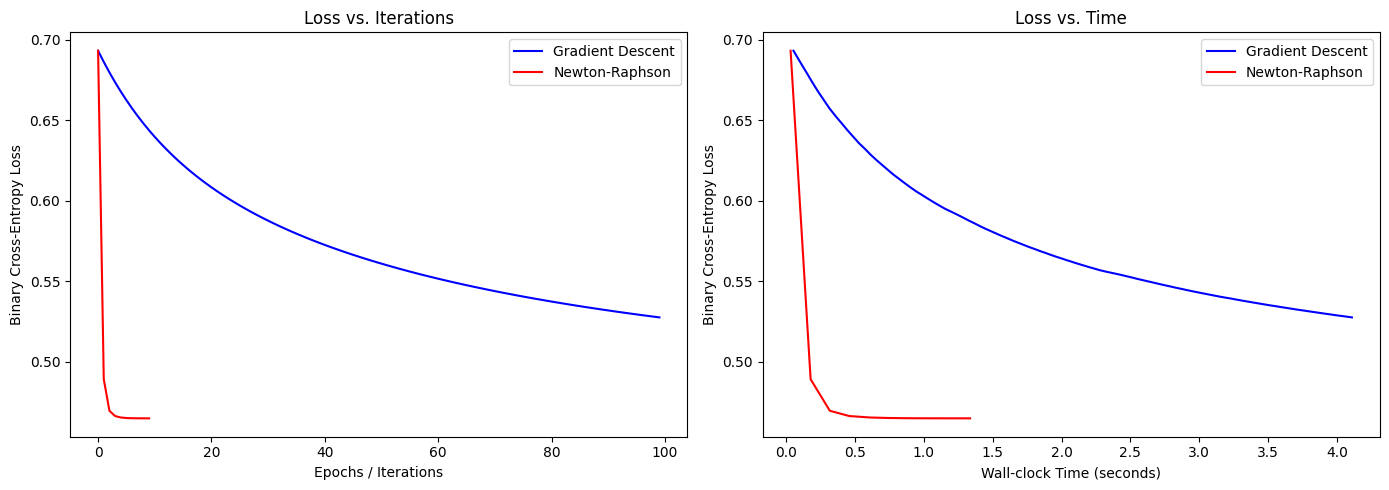

In [13]:
plot_convergence(gd_binary_model, newton_binary_model)

In [14]:
print("Evaluating Multiclass Strategies")
multiclass_output = evaluate_multiclass_strategies(
    X_train_processed,
    y_train_np,
    X_val_processed,
    y_val_np,
)

multiclass_results = multiclass_output["scores"]
multiclass_models = multiclass_output["models"]
multiclass_val_predictions = multiclass_output["val_predictions"]

Evaluating Multiclass Strategies
Training One-vs-Rest...
Training One-vs-One...
Training Direct Softmax...
One-vs-Rest Macro-F1 Score: 0.2861
One-vs-One Macro-F1 Score: 0.3351
Direct Softmax Macro-F1 Score: 0.2993


### Phân tích kết quả

**1. Phân tích Tốc độ hội tụ: Gradient Descent vs. Newton-Raphson**

Dựa vào hai biểu đồ phân tích **Loss vs. Iterations** và **Loss vs. Time**:
- **Về số vòng lặp:** Thuật toán Newton-Raphson (đường màu đỏ) thể hiện sự vượt trội hoàn toàn với tốc độ hội tụ bậc hai. Nó chỉ mất khoảng 10 vòng lặp để đạt mức loss tối thiểu (~0.47), trong khi Gradient Descent (đường màu xanh) hội tụ tuyến tính và vẫn đang giảm từ từ ở mốc 100 vòng lặp. Điều này là do Newton-Raphson sử dụng cả đạo hàm bậc hai để xác định độ cong của hàm mất mát, giúp nó hướng thẳng tới điểm cực tiểu.
- **Về thời gian thực thi:** Thông thường, việc tính toán và nghịch đảo ma trận Hessian trong Newton-Raphson rất tốn kém thời gian ($O(d^3)$ với $d$ là số đặc trưng). Tuy nhiên, tập dữ liệu Covertype chỉ có 54 đặc trưng (một con số tương đối nhỏ). Do đó, chi phí tính toán cho mỗi vòng lặp thấp, khiến cho lợi thế từ việc giảm thiểu số lượng vòng lặp vượt trội hoàn toàn. Kết quả là Newton-Raphson không chỉ cần ít vòng lặp hơn mà còn chạy nhanh hơn Gradient Descent xét trên thời gian thực.

**2. Phân tích Chiến lược Đa lớp**

Dựa trên điểm **Macro-F1 Score**: One-vs-Rest (0.2861) < Direct Softmax (0.2993) < One-vs-One (0.3351).
- Tập dữ liệu Covertype có sự chênh lệch số lượng mẫu cực lớn giữa các loại rừng (ví dụ: loại 1 và 2 chiếm đa số, trong khi loại 4 lại rất ít). Điểm số Macro-F1 đánh giá sự công bằng giữa các lớp, nên nó phản ánh rõ sự yếu kém của mô hình trên các lớp thiểu số.
- Chiến lược One-vs-Rest bắt buộc mỗi mô hình nhị phân phải phân biệt một lớp với *tất cả các lớp còn lại kết hợp lại*, tạo ra sự mất cân bằng dữ liệu cực kỳ nghiêm trọng. Ngược lại, One-vs-One chỉ so sánh từng cặp lớp riêng biệt. Việc này giúp giảm bớt áp lực mất cân bằng và cho phép mô hình học các decision boundaries chi tiết hơn giữa các cặp loại rừng khó phân biệt.
- Direct Softmax hoạt động tốt hơn One-vs-Rest nhưng vẫn kém hơn One-vs-One một chút trong trường hợp này, vì One-vs-One linh hoạt hơn trong việc tạo ra các ranh giới tuyến tính phân mảnh cục bộ.
- **Nhận xét tổng quan:** Điểm Macro-F1 nhìn chung dao động ở mức khá thấp (~0.28 - 0.33). Điều này minh chứng rằng bộ dữ liệu Covertype mang tính phi tuyến tính cao. Các mô hình như Logistic Regression sẽ gặp giới hạn "underfitting" trừ khi ta kết hợp thêm các bước Feature Engineering phức tạp (như tạo Polynomial features).

## **2. LDA vs. QDA**

### 2.1 Implementing Discriminant Analysis and Fisher Ratio

In [15]:
class LinearDiscriminantAnalysis:
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.priors_ = None
        self.means_ = None
        self.coef_ = None
        self.intercept_ = None
        self.scalings_ = None 
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        self.priors_ = np.zeros(n_classes)
        self.means_ = np.zeros((n_classes, n_features))

        # 1. Calculate priors and class means
        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.priors_[i] = X_c.shape[0] / n_samples
            self.means_[i, :] = np.mean(X_c, axis=0)

        # 2. Calculate Shared Covariance Matrix (Sw)
        Sw = np.zeros((n_features, n_features))
        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            diff = X_c - self.means_[i, :]
            Sw += np.dot(diff.T, diff)
        
        Sigma = Sw / (n_samples - n_classes)
        Sigma += np.eye(n_features) * 1e-6 #  numerical stability
        Sigma_inv = np.linalg.pinv(Sigma)

        # 3. Parameters for Classification (Linear Decision Boundary)
        self.coef_ = np.dot(self.means_, Sigma_inv)
        self.intercept_ = -0.5 * np.diag(np.dot(self.means_, np.dot(Sigma_inv, self.means_.T))) + np.log(self.priors_)

        # 4. Parameters for Dimensionality Reduction (Sb and Eigen decomposition)
        global_mean = np.mean(X, axis=0)
        Sb = np.zeros((n_features, n_features))
        for i, c in enumerate(self.classes_):
            N_c = X[y == c].shape[0]
            mean_diff = (self.means_[i, :] - global_mean).reshape(-1, 1)
            Sb += N_c * np.dot(mean_diff, mean_diff.T)

        # Solve eigenvalue problem: Sw^-1 * Sb
        A = np.dot(np.linalg.pinv(Sw), Sb)
        eigenvalues, eigenvectors = np.linalg.eig(A)

        # Sort eigenvectors by eigenvalues in descending order
        eigenvectors = eigenvectors.T
        idxs = np.argsort(abs(eigenvalues))[::-1]
        eigenvectors = eigenvectors[idxs]

        # Store eigenvectors for projection
        if self.n_components is not None:
            self.scalings_ = np.real(eigenvectors[0:self.n_components].T)
        else:
            self.scalings_ = np.real(eigenvectors.T)

        return self

    def predict(self, X):
        """Linear score function: delta_c(x) = Wx + b"""
        scores = np.dot(X, self.coef_.T) + self.intercept_
        return self.classes_[np.argmax(scores, axis=1)]

    def transform(self, X):
        """Project data into lower dimensional space"""
        return np.dot(X, self.scalings_)

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

In [16]:
class QuadraticDiscriminantAnalysis:
    def __init__(self):
        self.priors_ = None
        self.means_ = None
        self.cov_invs_ = None
        self.log_dets_ = None
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        self.priors_ = np.zeros(n_classes)
        self.means_ = np.zeros((n_classes, n_features))
        self.cov_invs_ = []
        self.log_dets_ = []

        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.priors_[i] = X_c.shape[0] / n_samples
            self.means_[i, :] = np.mean(X_c, axis=0)

            # Separate Covariance matrix for each class c
            diff = X_c - self.means_[i, :]
            cov = np.dot(diff.T, diff) / (X_c.shape[0] - 1)
            cov += np.eye(n_features) * 1e-6 # numerical stability
            
            self.cov_invs_.append(np.linalg.pinv(cov))
            
            # Compute log determinant
            sign, logdet = np.linalg.slogdet(cov)
            self.log_dets_.append(logdet)

        return self

    def predict(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        scores = np.zeros((n_samples, n_classes))

        # Quadratic score function
        for i in range(n_classes):
            diff = X - self.means_[i, :]
            # Vectorized quadratic term computation: (x-u)^T * Sigma^-1 * (x-u)
            term1 = -0.5 * self.log_dets_[i]
            term2 = -0.5 * np.sum(np.dot(diff, self.cov_invs_[i]) * diff, axis=1)
            term3 = np.log(self.priors_[i])
            scores[:, i] = term1 + term2 + term3

        return self.classes_[np.argmax(scores, axis=1)]

In [17]:
print("Training LDA ...")
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_processed, y_train_np)
preds_lda = lda.predict(X_test_processed)
print(f"Macro-F1 Score: {f1_score(y_test_np, preds_lda, average='macro'):.4f}")

print("Training QDA ...")
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_processed, y_train_np)
preds_qda = qda.predict(X_test_processed)
print(f"Macro-F1 Score: {f1_score(y_test_np, preds_qda, average='macro'):.4f}")

# Lưu xác suất để phục vụ PR/AP và calibration ở notebook 04
scores_lda = np.dot(X_test_processed, lda.coef_.T) + lda.intercept_
exp_scores_lda = np.exp(scores_lda - np.max(scores_lda, axis=1, keepdims=True))
proba_lda = exp_scores_lda / np.sum(exp_scores_lda, axis=1, keepdims=True)

n_classes = len(qda.classes_)
scores_qda = np.zeros((X_test_processed.shape[0], n_classes))
for i in range(n_classes):
    diff = X_test_processed - qda.means_[i, :]
    term1 = -0.5 * qda.log_dets_[i]
    term2 = -0.5 * np.sum(np.dot(diff, qda.cov_invs_[i]) * diff, axis=1)
    term3 = np.log(qda.priors_[i])
    scores_qda[:, i] = term1 + term2 + term3
exp_scores_qda = np.exp(scores_qda - np.max(scores_qda, axis=1, keepdims=True))
proba_qda = exp_scores_qda / np.sum(exp_scores_qda, axis=1, keepdims=True)

Training LDA ...
Macro-F1 Score: 0.5123
Training QDA ...
Macro-F1 Score: 0.2335


#### Phân tích kết quả
**LDA (0.5123) áp đảo hoàn toàn QDA (0.2335)**. Sự chênh lệch lớn này bắt nguồn từ **sự không tương thích giữa thuật toán QDA và đặc thù của bộ dữ liệu Covertype**:

- Bộ dữ liệu Covertype có 54 features, nhưng trong đó chứa tới 44 biến nhị phân (được one-hot encoding cho `Wilderness_Area` và `Soil_Type`). Thuật toán QDA hoạt động bằng cách tính toán ma trận hiệp phương sai (covariance matrix) **riêng biệt cho từng nhãn (class)**. Việc tính toán ma trận này trên các biến nhị phân thưa thớt thường dẫn đến tình trạng ma trận bị suy biến, khiến QDA không thể ước lượng chính xác và dẫn đến overfitting nghiêm trọng, làm giảm điểm F1.
- Ngược lại, LDA giả định rằng tất cả các class đều dùng **chung một ma trận hiệp phương sai duy nhất**. Việc dùng chung ma trận giúp LDA tính toán ổn định hơn, chịu lỗi tốt hơn trước dữ liệu one-hot và không bị sụp đổ như QDA.

### **2.2 Xếp hạng Đặc trưng thông qua Chỉ số Fisher (Fisher Ratio)**
Để hiểu rõ những đặc trưng nào đang dẫn dắt các quyết định của mô hình, ta sử dụng Chỉ số Fisher, ký hiệu là $J(w)$. Chỉ số này đánh giá khả năng phân biệt của từng đặc trưng bằng cách so sánh phương sai *giữa* các lớp với phương sai *trong nội bộ* các lớp.

Về mặt toán học, đối với một đặc trưng đơn lẻ, chỉ số này được định nghĩa như sau:
$$J = \frac{\sum_{c} N_c (\mu_{c} - \mu_{global})^2}{\sum_c N_c \sigma_{c}^2}$$

Chỉ số Fisher càng cao cho thấy đặc trưng đó có giá trị trung bình giữa các lớp cách xa nhau so với độ phân tán nội bộ của các lớp đó. Những đặc trưng như vậy có khả năng phân biệt rất cao vì chúng phân tách các danh mục mục tiêu một cách tự nhiên dọc theo trục tọa độ đó.


In [18]:
def calculate_fisher_ratio(X, y):
    """
    Calculates the Fisher ratio J(w) for each feature to rank discriminative power.
    J = (Between-class variance) / (Within-class variance)
    """
    classes = np.unique(y)
    global_mean = np.mean(X, axis=0)
    
    between_class_var = np.zeros(X.shape[1])
    within_class_var = np.zeros(X.shape[1])
    
    for c in classes:
        X_c = X[y == c]
        N_c = X_c.shape[0]
        class_mean = np.mean(X_c, axis=0)
        class_var = np.var(X_c, axis=0)
        
        between_class_var += N_c * (class_mean - global_mean)**2
        within_class_var += N_c * class_var
        
    fisher_ratios = between_class_var / (within_class_var + 1e-15)
    return fisher_ratios

In [19]:
print("\nCalculating Fisher Ratios...")
fisher_scores = calculate_fisher_ratio(X_train_processed, y_train_np)
top_indices = np.argsort(fisher_scores)[::-1]

feature_names_processed = continuous_features_final + binary_cols

top_features_df = pd.DataFrame({
    "Rank": range(1, len(top_indices) + 1),
    "Feature Name": [feature_names_processed[i] for i in top_indices],
    "Feature Index": top_indices,
    "Fisher Ratio": fisher_scores[top_indices],
})
top_features_df = top_features_df.set_index("Rank")
top_features_df["Fisher Ratio"] = top_features_df["Fisher Ratio"].map("{:.6f}".format)

print("Top 5 Features by Discriminative Power (Fisher Ratio):")
display(top_features_df)


Calculating Fisher Ratios...
Top 5 Features by Discriminative Power (Fisher Ratio):


,Feature Name,Feature Index,Fisher Ratio
Rank,,,
1,Elevation,0,1.561993
2,Wilderness_Area4,15,1.196687
3,Soil_Type10,25,0.290805
4,Distance_To_Amenities,11,0.146503
5,Soil_Type4,19,0.131493
6,Soil_Type38,53,0.128486
7,Soil_Type39,54,0.125457
8,Soil_Type3,18,0.120991
9,Wilderness_Area1,12,0.107085


#### Phân tích kết quả
- Hai đặc trưng `Elevation` và `Wilderness_Area4` có Fisher Ratio cao vượt trội (đều > 1.0). Điều này cho thấy đây là hai yếu tố mang tính quyết định nhất giúp phân tách các loại rừng. Mức độ chênh lệch giữa các lớp (between-class variance) của hai đặc trưng này lớn hơn nhiều so với sự biến thiên bên trong từng lớp (within-class variance).
- Có một sự sụt giảm rất mạnh về điểm số từ vị trí thứ 2 xuống thứ 3 (từ $1.19$ rơi xuống chỉ còn $0.29$). Các đặc trưng từ Top 3 trở đi (`Soil_Type10`, `Distance_To_Amenities`, `Soil_Type4`) có khả năng phân tách tuyến tính độc lập khá kém, khi mà phương sai nội lớp lấn át phương sai giữa các lớp.

**Kết luận:** Nếu ta sử dụng các mô hình tuyến tính (như Logistic Regression, LDA), `Elevation` chắc chắn là một feature tốt cho mô hình. Với những đặc trưng có điểm Fisher Ratio quá thấp (gần $0$), ta có thể cân nhắc loại bỏ để giảm bớt độ phức tạp, giảm nhiễu và tăng tốc độ huấn luyện mà không làm giảm nhiều hiệu suất của mô hình.

### **2.3 Chiếu 2D và Vẽ Ranh giới Quyết định**
Trong notebook này, ta sẽ chiếu tập dữ liệu đa chiều phức tạp vào một không gian con 2D bằng cách sử dụng hai vectơ riêng tương ứng với các giá trị riêng lớn nhất. Khi được vẽ cùng với các contours tạo ra từ việc đánh giá thuật toán LDA trên một lưới tọa độ 2D, biểu đồ thu được minh họa rõ ràng các siêu phẳng tuyến tính mà mô hình LDA thiết lập để phân chia không gian dữ liệu.

In [20]:
def plot_lda_2d(X, y, lda_model=None):
    """Projects data into 2D using LDA, calculates boundaries, and plots them."""
    
    # 1. Project into 2D Subspace
    lda_2d = LinearDiscriminantAnalysis(n_components=2)
    X_projected = lda_2d.fit_transform(X, y)
    
    # 2. Train a new LDA classifier on the 2D data to easily map the decision boundaries
    lda_classifier_2d = LinearDiscriminantAnalysis()
    lda_classifier_2d.fit(X_projected, y)

    # 3. Create meshgrid for background contours
    x_min, x_max = X_projected[:, 0].min() - 1, X_projected[:, 0].max() + 1
    y_min, y_max = X_projected[:, 1].min() - 1, X_projected[:, 1].max() + 1
    # Step size can be adjusted for performance vs resolution
    step_size = 0.02 
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size), np.arange(y_min, y_max, step_size))

    # 4. Predict the meshgrid points
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = lda_classifier_2d.predict(mesh_points)
    Z = Z.reshape(xx.shape)
    levels = np.arange(Z.min() - 0.5, Z.max() + 1.5, 1)
    
    # 5. Plotting boundaries and scatter
    plt.figure(figsize=(12, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', levels=levels)
    
    sns.scatterplot(
        x=X_projected[:, 0], y=X_projected[:, 1], 
        hue=y, palette='viridis', s=10, alpha=0.8, edgecolor=None
    )
    
    plt.title('2D LDA Projection with Linear Decision Boundaries')
    plt.xlabel('Linear Discriminant 1')
    plt.ylabel('Linear Discriminant 2')
    plt.legend(title='Cover Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

Plotting 2D Decision Boundaries ...


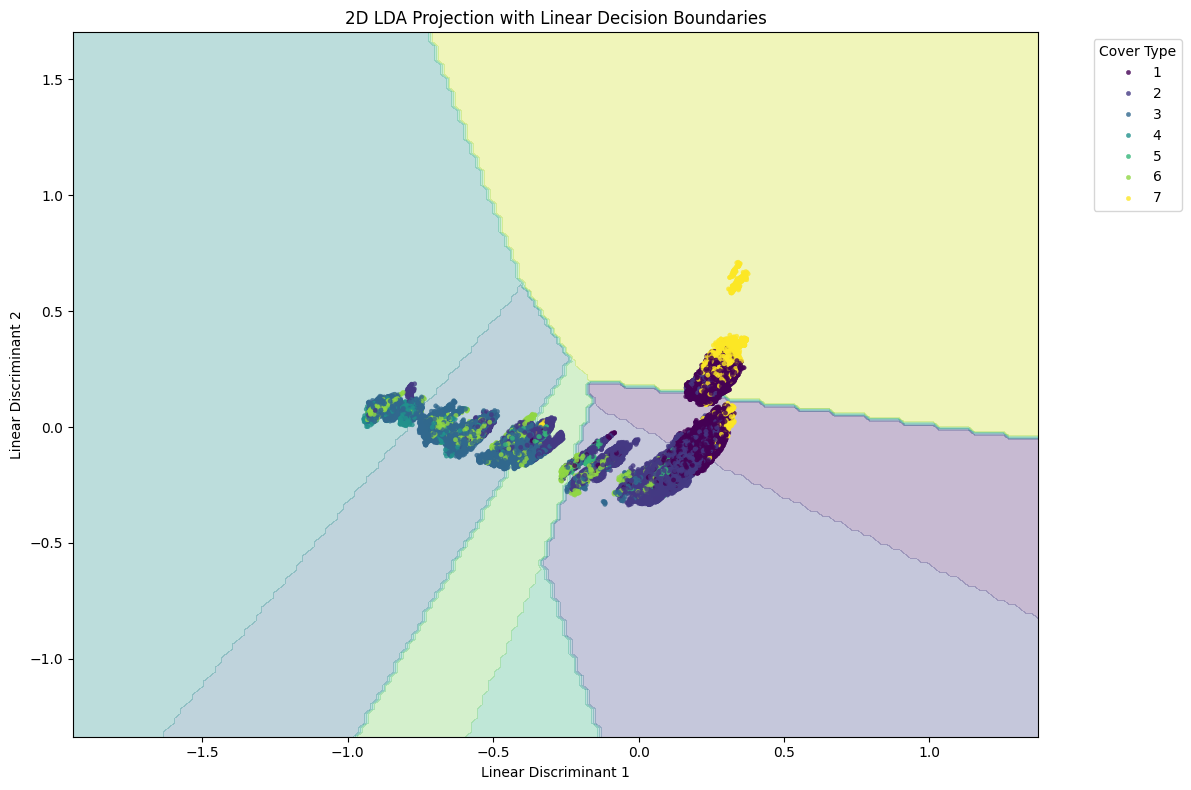

In [21]:
print("Plotting 2D Decision Boundaries ...")
plot_lda_2d(X_train_processed, y_train_np)

#### Phân tích kết quả
- Điểm đáng chú ý nhất là các điểm dữ liệu của 7 loại rừng bị chồng chéo lên nhau rất nhiều, đặc biệt là ở các cụm dữ liệu trung tâm và góc dưới bên phải. Các màu sắc đan xen dày đặc cho thấy các lớp dữ liệu không bị cô lập rõ ràng trong không gian quy chiếu này.
- Mặc dù không gian nền đã được chia thành các vùng quyết định với các đường biên thẳng nhưng do sự phân bố đan xen của dữ liệu, một lượng lớn các điểm đang rơi vào các vùng màu nền không khớp với nhãn thực tế của chúng (ví dụ: điểm màu vàng nằm trong vùng nền tím).

**Kết luận:** Việc chỉ sử dụng 2 trục (2 thành phần LDA đầu tiên) là **không đủ** để phân tách rõ ràng 7 lớp của bộ dữ liệu Covertype này. Cấu trúc của dữ liệu dường như phức tạp hơn nhiều.

### **2.4 Khi nào nên sử dụng LDA so với QDA**

**LDA:** LDA là một bộ phân loại dựa trên định lý Bayes, giả định rằng mỗi lớp tuân theo phân phối Gaussian đa biến với một **ma trận hiệp phương sai chung** ($\Sigma_k = \Sigma$). Giả định đơn giản hóa này loại bỏ các số hạng bậc hai trong hàm phân biệt, dẫn đến **ranh giới quyết định tuyến tính**. Điểm phân loại được tính bằng công thức:
$$\delta_k(x) = x^T \Sigma^{-1} \mu_k - \frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k + \log(P(k))$$
Vì LDA chỉ ước lượng một ma trận hiệp phương sai duy nhất cho tất cả các lớp, tổng số tham số của nó tăng theo $\mathcal{O}(Kd + d^2)$, thấp hơn nhiều so với QDA, giúp nó đạt hiệu quả cao về mặt thống kê. Ràng buộc này đóng vai trò như một bộ điều chuẩn ngầm định (implicit regularizer), do đó LDA thường được ưu tiên khi kích thước mẫu $N$ nhỏ so với số chiều đặc trưng $d$, hoặc khi các ma trận hiệp phương sai của các lớp thực sự tương đồng nhau.

**QDA:** QDA mở rộng LDA bằng cách cho phép mỗi lớp có **ma trận hiệp phương sai riêng biệt** ($\Sigma_k \neq \Sigma_j$), trong khi vẫn giả định các phân phối có điều kiện của lớp là Gaussian. Tính linh hoạt bổ sung này giữ lại các số hạng bậc hai trong hàm phân biệt, tạo ra các **ranh giới quyết định bậc hai** (ví dụ: hình elip hoặc hyperbol). Điểm phân loại là:
$$\delta_k(x) = -\frac{1}{2} \log |\Sigma_k| - \frac{1}{2} (x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k) + \log(P(k))$$
QDA có độ phức tạp tham số cao hơn đáng kể, tăng theo $\mathcal{O}(Kd^2)$, vì nó phải ước lượng một ma trận hiệp phương sai đầy đủ cho từng lớp trong số $K$ lớp. Mặc dù điều này giúp giảm bias và cho phép mô hình hóa các mối quan hệ đặc trưng không đồng nhất, nhưng nó lại làm tăng phương sai và nguy cơ overfitting. Do đó, QDA phù hợp nhất khi $N \gg d$ và khi cấu trúc hiệp phương sai đặc thù của từng lớp có sự khác biệt lớn.

## **3. Perceptron & Regularization**

### 3.1 Perceptron Algorithm & Convergence
**Perceptron** là mô hình học máy cơ bản dùng để **phân loại nhị phân** bằng cách tìm một đường thẳng (hoặc siêu phẳng) chia tách hai lớp dữ liệu. Nếu dữ liệu có thể phân tách tuyến tính hoàn toàn, thuật toán **chắc chắn hội tụ**. Nếu không, nó sẽ lặp vô hạn (đó là lý do ta cần giới hạn `max_iter`).

* **`__init__`**: Khởi tạo tốc độ học (`learning_rate`) và số vòng lặp tối đa (`max_iter`).
* **`fit(X, y)`**: Quá trình huấn luyện.
    1.  Chuyển đổi nhãn `y` về chuẩn toán học $\{-1, 1\}$.
    2.  Lặp qua dữ liệu: Tính giá trị dự đoán `activation`.
    3.  **Sửa lỗi:** Kiểm tra `target * activation <= 0`. Nếu đúng (tức là dự đoán sai), cập nhật lại trọng số (`weights`) và độ lệch (`bias`) theo hướng chính xác hơn.
    4.  **Dừng sớm:** Nếu duyệt qua toàn bộ dữ liệu mà không có lỗi (`errors == 0`), mô hình đã hội tụ, vòng lặp dừng ngay lập tức.
* **`predict(X)`**: Dùng trọng số đã học để dự đoán dữ liệu mới. Trả về nhãn `1` nếu kết quả tính toán $\ge 0$, ngược lại trả về `0`.

In [22]:
class Perceptron:
    """An implementation of the standard Perceptron algorithm."""
    def __init__(self, learning_rate=0.1, max_iter=1000):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.weights = None
        self.bias = 0
        self.errors_per_epoch = []
        
    def fit(self, X, y):
        # Perceptron expects targets in {-1, 1}
        y_mod = np.where(y <= 0, -1, 1)
        N, D = X.shape
        self.weights = np.zeros(D)
        self.bias = 0
        self.errors_per_epoch = []
        
        for epoch in range(self.max_iter):
            errors = 0
            for xi, target in zip(X, y_mod):
                activation = np.dot(xi, self.weights) + self.bias
                if target * activation <= 0:
                    self.weights += self.learning_rate * target * xi
                    self.bias += self.learning_rate * target
                    errors += 1
            self.errors_per_epoch.append(errors)
            if errors == 0:
                break 
                
    def predict(self, X):
        activation = np.dot(X, self.weights) + self.bias
        return np.where(activation >= 0, 1, 0)

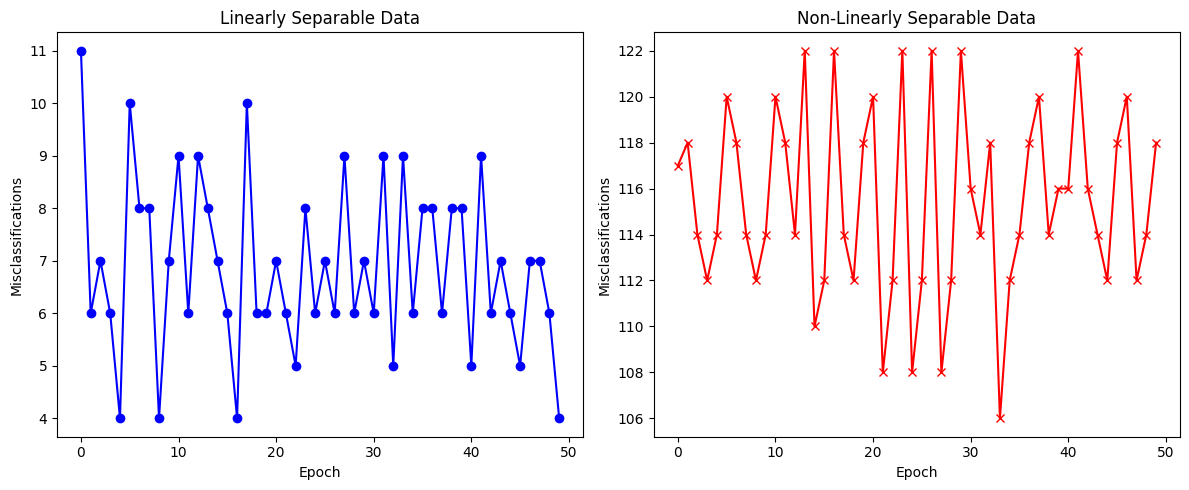

In [23]:
def demonstrate_perceptron():
    """Demonstrates Perceptron convergence on separable vs non-separable data"""

    # 1. Linearly Separable Data
    X_sep, y_sep = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                                       n_clusters_per_class=1, random_state=SEED, class_sep=2.0)
    # 2. Non-Linearly Separable Data
    X_non_sep, y_non_sep = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=SEED)
    
    p_sep = Perceptron(learning_rate=0.1, max_iter=50)
    p_sep.fit(X_sep, y_sep)
    
    p_non_sep = Perceptron(learning_rate=0.1, max_iter=50)
    p_non_sep.fit(X_non_sep, y_non_sep)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(p_sep.errors_per_epoch, marker='o', color='blue')
    axes[0].set_title('Linearly Separable Data')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Misclassifications')
    
    axes[1].plot(p_non_sep.errors_per_epoch, marker='x', color='red')
    axes[1].set_title('Non-Linearly Separable Data')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Misclassifications')
    
    plt.tight_layout()
    plt.show()

demonstrate_perceptron()

#### Phân tích kết quả

- **Biểu đồ trái (Linearly Separable Data):** Mặc dù được kỳ vọng là dữ liệu có thể phân chia tuyến tính, thuật toán vẫn không hội tụ về 0 lỗi sau 50 epoch (số lỗi dao động từ 4 đến 11). Nguyên nhân là do hàm `make_classification` với `class_sep=2.0` có thể vẫn sinh ra một vài điểm dữ liệu nhiễu lấn sang ranh giới của lớp kia khiến tập dữ liệu không phân chia tuyến tính *hoàn hảo*. Perceptron tiêu chuẩn rất nhạy cảm với điều này. Ngoài ra, tốc độ học (`0.1`) cũng có thể khiến nghiệm "nhảy" qua lại quanh điểm tối ưu.

- **Biểu đồ phải (Non-Linearly Separable Data):** Số lượng mẫu bị phân loại sai rất cao (106 - 122 trên tổng số 200 mẫu) và dao động với biên độ lớn qua các epoch. Dữ liệu được tạo bởi `make_circles` có dạng vòng tròn lồng nhau. Perceptron là một mô hình tuyến tính, do đó nó hoàn toàn bất lực trước dữ liệu có cấu trúc phi tuyến tính. Quá trình cập nhật trọng số sẽ lặp lại vô ích mà không bao giờ tìm được ranh giới đúng.

### 3.2 L1 vs. L2 Regularization & Sparsity Analysis
Regularization nhằm mục đích ngăn chặn hiện tượng overfitting bằng cách xử phạt các tham số mô hình có giá trị lớn. Ta đã triển khai hai biến thể trong mô hình Hồi quy Logistic:

* **L1 Regularization (Lasso):** Áp dụng hình phạt theo giá trị tuyệt đối: $\lambda \sum |w_i|$. Vì số hạng hình phạt L1 tạo ra một vùng ràng buộc hình thoi trong không gian tham số, các đường đồng mức của hàm mất mát trong gradient descent thường giao với vùng ràng buộc này tại các trục tọa độ. Điều này thúc đẩy các trọng số của những đặc trưng ít quan trọng về chính xác bằng 0 một cách mạnh m.
* **L2 Regularization (Ridge):** Áp dụng hình phạt theo bình phương: $\frac{\lambda}{2} \sum w_i^2$. Vùng ràng buộc hình tròn của L2 thu hẹp tất cả các trọng số về phía 0 một cách mượt mà theo tỷ lệ, nhưng hiếm khi ép chúng bằng không một cách tuyệt đối.

In [24]:
def analyze_regularization_sparsity(X_train, y_train, threshold = 1e-4 ):
    """Compares the sparsity of weights between L1 and L2 regularization."""
    log_l1 = LogisticRegression(penalty='l1', lambda_reg=0.5, learning_rate=0.1, max_iter=200)
    log_l1.fit_gd_multiclass(X_train, y_train)
    
    log_l2 = LogisticRegression(penalty='l2', lambda_reg=0.5, learning_rate=0.1, max_iter=200)
    log_l2.fit_gd_multiclass(X_train, y_train)
    
    # Exclude bias
    zero_weights_l1 = np.sum(np.abs(log_l1.weights) < threshold)
    zero_weights_l2 = np.sum(np.abs(log_l2.weights) < threshold)
    total_weights = log_l1.weights.size
    assert log_l1.weights.size == log_l2.weights.size
    
    print(f"Total Weights: {total_weights}")
    print(f"Near-Zero Weights (L1): {zero_weights_l1} (Feature selection effect)")
    print(f"Near-Zero Weights (L2): {zero_weights_l2} (Shrinkage effect)")

analyze_regularization_sparsity(X_train_processed, y_train)

Total Weights: 399
Near-Zero Weights (L1): 392 (Feature selection effect)
Near-Zero Weights (L2): 42 (Shrinkage effect)


#### Phân tích kết quả

- L1 đã triệt tiêu gần như toàn bộ trọng số (392/399, tương đương ~98%). Điều này minh họa rất rõ nét khả năng chọn lọc đặc trưng.
- Ngược lại, L2 phân bổ hình phạt dàn trải và chỉ có 42/399 trọng số tiến sát 0 (~10%). Nó đúng với tính chất đặc trưng của L2: thu nhỏ biên độ của toàn bộ trọng số để ngăn overfitting, nhưng hiếm khi loại bỏ hoàn toàn bất kỳ đặc trưng nào, giúp mô hình tổng hợp được thông tin từ nhiều biến số.

### 3.2 Stratified 5-Fold Cross Validation


Phương pháp cross-validation tiêu chuẩn có thể gây ra phương sai nếu các folds được lấy mẫu ngẫu nhiên làm mất cân bằng phân phối lớp. Stratified CV giúp duy trì tỷ lệ của các lớp mục tiêu trong cả tập con huấn luyện và kiểm định cho mỗi fold. Điều này đặc biệt quan trọng đối với các tập dữ liệu như Covertype — vốn có tần suất các lớp rất chênh lệch — nhằm đảm bảo chỉ số đánh giá macro-F1 vẫn đáng tin cậy trên toàn bộ hyperparameter grid.

In [25]:
def tune_regularization(
    X,
    y,
    lambda_grid=(0.001, 0.01, 0.1, 1.0, 10.0),
    penalty='l2',
    learning_rate=0.1,
    max_iter=100,
):
    """Uses Stratified 5-Fold CV to find the best lambda and returns tuning details."""
    from sklearn.metrics import precision_score, recall_score

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    best_lambda = None
    best_score = -1.0
    cv_table = []

    X_arr = X if isinstance(X, np.ndarray) else X.to_numpy()
    y_arr = y if isinstance(y, np.ndarray) else y.to_numpy()

    for lam in lambda_grid:
        print(f"Train model with lambda = {lam}")
        fold_acc = []
        fold_precision = []
        fold_recall = []
        fold_f1 = []

        for train_idx, val_idx in skf.split(X_arr, y_arr):
            X_tr, X_va = X_arr[train_idx], X_arr[val_idx]
            y_tr, y_va = y_arr[train_idx], y_arr[val_idx]

            model = LogisticRegression(
                penalty=penalty,
                lambda_reg=lam,
                learning_rate=learning_rate,
                max_iter=max_iter,
            )
            model.fit_gd_multiclass(X_tr, y_tr)

            y_pred = model.predict(X_va)
            fold_acc.append(float(np.mean(y_pred == y_va)))
            fold_precision.append(float(precision_score(y_va, y_pred, average='macro', zero_division=0)))
            fold_recall.append(float(recall_score(y_va, y_pred, average='macro', zero_division=0)))
            fold_f1.append(float(f1_score(y_va, y_pred, average='macro', zero_division=0)))

        metrics_row = {
            'penalty': penalty,
            'lambda': float(lam),
            'accuracy_mean': float(np.mean(fold_acc)),
            'accuracy_std': float(np.std(fold_acc)),
            'precision_macro_mean': float(np.mean(fold_precision)),
            'precision_macro_std': float(np.std(fold_precision)),
            'recall_macro_mean': float(np.mean(fold_recall)),
            'recall_macro_std': float(np.std(fold_recall)),
            'macro_f1_mean': float(np.mean(fold_f1)),
            'macro_f1_std': float(np.std(fold_f1)),
        }
        cv_table.append(metrics_row)

        if metrics_row['macro_f1_mean'] > best_score:
            best_score = metrics_row['macro_f1_mean']
            best_lambda = lam

    print(f"Best parameter (lambda): {best_lambda}")
    print(f"Best Macro-F1 Score: {best_score:.4f}")

    final_model = LogisticRegression(
        penalty=penalty,
        lambda_reg=best_lambda,
        learning_rate=learning_rate,
        max_iter=200,
    )
    final_model.fit_gd_multiclass(X_arr, y_arr)

    return {
        'penalty': penalty,
        'best_lambda': float(best_lambda),
        'best_macro_f1_mean': float(best_score),
        'cv_table': cv_table,
        'final_model': final_model,
    }

def display_cv_table(tuning_result):
    """Display CV results as formatted tables."""
    df = pd.DataFrame(tuning_result['cv_table'])
    display_df = pd.DataFrame({
        'λ (lambda)':       df['lambda'],
        'Accuracy':         df.apply(lambda r: f"{r['accuracy_mean']:.4f} ± {r['accuracy_std']:.4f}", axis=1),
        'Precision (macro)':df.apply(lambda r: f"{r['precision_macro_mean']:.4f} ± {r['precision_macro_std']:.4f}", axis=1),
        'Recall (macro)':   df.apply(lambda r: f"{r['recall_macro_mean']:.4f} ± {r['recall_macro_std']:.4f}", axis=1),
        'F1 (macro)':       df.apply(lambda r: f"{r['macro_f1_mean']:.4f} ± {r['macro_f1_std']:.4f}", axis=1),
    })
    penalty = tuning_result['penalty'].upper()
    print(f"Stratified 5-Fold CV Results — {penalty} Regularization")

    display(display_df)

# X_temp_raw is train + val from the original dataset (80%).
X_processed = preprocess_pipeline.fit_transform(X_temp_raw)
y_temp_np = y_temp.to_numpy()

lambda_tuning_l1 = tune_regularization(X_processed, y_temp_np, penalty='l1')
lambda_tuning_l2 = tune_regularization(X_processed, y_temp_np, penalty='l2')

display_cv_table(lambda_tuning_l1)
display_cv_table(lambda_tuning_l2)


Train model with lambda = 0.001
Train model with lambda = 0.01
Train model with lambda = 0.1
Train model with lambda = 1.0
Train model with lambda = 10.0
Best parameter (lambda): 0.001
Best Macro-F1 Score: 0.2737
Train model with lambda = 0.001
Train model with lambda = 0.01
Train model with lambda = 0.1
Train model with lambda = 1.0
Train model with lambda = 10.0
Best parameter (lambda): 0.001
Best Macro-F1 Score: 0.2749
Stratified 5-Fold CV Results — L1 Regularization


,λ (lambda),Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,0.001,0.6680 ± 0.0005,0.2806 ± 0.0007,0.2743 ± 0.0006,0.2737 ± 0.0006
1,0.010,0.6517 ± 0.0009,0.2840 ± 0.0014,0.2405 ± 0.0006,0.2436 ± 0.0007
2,0.100,0.5265 ± 0.0002,0.1572 ± 0.0006,0.1586 ± 0.0001,0.1264 ± 0.0001
3,1.000,0.4876 ± 0.0000,0.0697 ± 0.0000,0.1429 ± 0.0000,0.0937 ± 0.0000
4,10.000,0.4876 ± 0.0000,0.0697 ± 0.0000,0.1429 ± 0.0000,0.0937 ± 0.0000


Stratified 5-Fold CV Results — L2 Regularization


,λ (lambda),Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,0.001,0.6691 ± 0.0004,0.2800 ± 0.0006,0.2762 ± 0.0006,0.2749 ± 0.0006
1,0.010,0.6676 ± 0.0006,0.2808 ± 0.0008,0.2734 ± 0.0007,0.2732 ± 0.0007
2,0.100,0.6449 ± 0.0013,0.2835 ± 0.0014,0.2303 ± 0.0005,0.2316 ± 0.0005
3,1.000,0.4884 ± 0.0001,0.1254 ± 0.0027,0.1432 ± 0.0000,0.0944 ± 0.0001
4,10.000,0.4876 ± 0.0000,0.0697 ± 0.0000,0.1429 ± 0.0000,0.0937 ± 0.0000


#### Phân tích kết quả
- Cả L1 và L2 regularization đều đạt kết quả Macro-F1 cao nhất tại $\lambda = 0.001$. Điều này cho thấy mô hình hoạt động tốt hơn khi ít bị kiểm soát trọng số.
- Khi $\lambda \ge 1.0$, hiệu suất của cả hai mô hình đều rất thấp (Accuracy dừng ở mức 48.76% và Macro-F1 rớt xuống dưới 10%). Điểm Recall khoảng 14.29% ($\approx \frac{1}{7}$ do tập Covertype có 7 class) cho thấy mô hình đã bị phạt quá mạnh, mất khả năng phân tách và có khả năng chỉ đang dự đoán toàn bộ dữ liệu vào majority class.
- L2 cho điểm Macro-F1 lớn nhất là 0.2749, cao hơn một chút so với 0.2737 của L1. L1 có xu hướng ép nhiều trọng số về 0, trong khi L2 thu nhỏ trọng số nhưng vẫn giữ lại tất cả đặc trưng. Điều này gợi ý rằng việc giữ lại thông tin từ toàn bộ các features có giá trị hơn là loại bỏ bớt chúng trong trường hợp này.
- Có một sự chênh lệch rất lớn giữa Accuracy (~67%) và Macro-F1 (~27%). Vì Macro-F1 tính trung bình hiệu suất của mọi lớp không màng đến kích thước của chúng, điểm Macro quá thấp này chứng tỏ mô hình đang dự đoán cực kỳ tệ ở minority classes dù dự đoán khá đúng majority class.

### 3.3 Custom Class-Weighted Loss
Trong các tập dữ liệu mất cân bằng nghiêm trọng, hàm Cross-Entropy thường vô tình gây ra định kiến cho mô hình nghiêng về các lớp đa số, bởi vì số lượng áp đảo của chúng sẽ chi phối gradient. Để khắc phục điều này, ta sẽ triển khai một phương thức tính toán hàm mất mát theo trọng số lớp tùy chỉnh:

$$E = -\sum_{n}\sum_{k} c_k t_{nk} \ln y_{nk}$$

Trong đó $t_{nk}$ là biến chỉ thị nhị phân thực tế cho lớp $k$, $y_{nk}$ là xác suất dự đoán, và trọng số lớp $c_k \propto N/N_k$ sẽ làm tăng hình phạt khi mô hình phân loại sai một lớp thiểu số. Về mặt toán học, điều này buộc thuật toán phải ưu tiên các lớp thiểu số theo tỷ lệ tương ứng, từ đó dịch chuyển các decision boundaries để tối đa hóa độ chính xác macro thay vì chỉ đơn thuần ưu tiên các lớp xuất hiện nhiều nhất.

Hàm loss đã được cài đặt vào trong class `LogisticRegression`, sau đây ta sẽ kiểm tra hiểu quả của nó.

In [26]:
def compare_class_weighted_loss(
    X_train, y_train, 
    X_val, y_val,
    sample_weight_train,
    class_weight_dict,
    learning_rate=0.1,
    max_iter=200,
):
    """
    Trains a Logistic Regression model with and without class-weighted loss,
    then compares their performance on the validation set.
    """

    # Model 1: Standard (no class weights)
    print("Training Logistic Regression WITHOUT class-weighted loss...")
    model_standard = LogisticRegression(learning_rate=learning_rate, max_iter=max_iter)
    model_standard.fit_gd_multiclass(X_train, y_train, sample_weight=None)

    # Model 2: Class-weighted loss
    print("Training Logistic Regression WITH class-weighted loss...")
    model_weighted = LogisticRegression(learning_rate=learning_rate, max_iter=max_iter)
    model_weighted.fit_gd_multiclass(X_train, y_train, sample_weight=sample_weight_train)

    # Evaluate both on validation set
    results = {}
    for name, model in [("Standard", model_standard), ("Class-Weighted", model_weighted)]:
        y_pred = model.predict(X_val)
        macro_f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
        accuracy = np.mean(y_pred == y_val)

        results[name] = {
            "Accuracy":f"{accuracy:.4f}",
            "Macro-F1":f"{macro_f1:.4f}",
        }
        print(f"[{name}] Accuracy={accuracy:.4f}  Macro-F1={macro_f1:.4f}")

    # Summary table
    comparison_df = pd.DataFrame(results).T
    comparison_df.index.name = "Model"
    print("\nComparison Summary:")
    display(comparison_df)

    return model_standard, model_weighted


model_standard, model_weighted = compare_class_weighted_loss(
    X_train_processed, y_train_np,
    X_val_processed, y_val_np,
    sample_weight_train=sample_weight_train,
    class_weight_dict=class_weight_dict,
)

Training Logistic Regression WITHOUT class-weighted loss...
Training Logistic Regression WITH class-weighted loss...
[Standard] Accuracy=0.6798  Macro-F1=0.2857
[Class-Weighted] Accuracy=0.4572  Macro-F1=0.3649

Comparison Summary:


,Accuracy,Macro-F1
Model,,
Standard,0.6798,0.2857
Class-Weighted,0.4572,0.3649


#### Phân tích kết quả
- Accuracy giảm mạnh từ 0.6798 xuống 0.4572. Ở mô hình Standard, Accuracy cao chủ yếu do mô hình dự đoán thiên vị vào các nhóm majority classes. Khi áp dụng trọng số (tỷ lệ nghịch với số lượng mẫu $c_k \propto N/N_k$), mô hình bị phạt nặng hơn khi đoán sai các nhóm thiểu số, dẫn đến việc phải hy sinh độ chính xác trên nhóm đa số. Do đó, tổng thể Accuracy bị giảm.
- Macro-F1 tăng rõ rệt từ 0.2857 lên 0.3649. Macro-F1 đánh giá hiệu suất mô hình bằng cách tính trung bình F1-score của *tất cả* các lớp một cách bình đẳng, không bị chi phối bởi số lượng mẫu của từng lớp. Việc chỉ số này tăng lên chứng tỏ mô hình Class-Weighted đã cải thiện đáng kể khả năng phân loại trên các nhóm rừng thiểu số.

# Export Artifacts for Notebook 04
Cell này lưu các artifact cần thiết cho notebook 04.

In [27]:
import os
import joblib
import numpy as np

artifacts_dir = "../results"
os.makedirs(artifacts_dir, exist_ok=True)

seed_value = int(globals().get('SEED', 42))

artifacts = {
    "seed": seed_value,
    "X_train_processed": X_train_processed,
    "X_val_processed": X_val_processed,
    "X_test_processed": X_test_processed,
    "y_train": y_train_np,
    "y_val": y_val_np,
    "y_test": y_test_np,
    "class_labels": np.sort(np.unique(y_train_np)),
    "class_weight_dict": class_weight_dict,
    "feature_names_processed": continuous_features_final + binary_cols,
    "shapes": {
        "X_train_processed": tuple(X_train_processed.shape),
        "X_val_processed": tuple(X_val_processed.shape),
        "X_test_processed": tuple(X_test_processed.shape),
        "y_train": tuple(y_train_np.shape),
        "y_val": tuple(y_val_np.shape),
        "y_test": tuple(y_test_np.shape),
    },
}

# Task 1
if "multiclass_results" in globals():
    artifacts["multiclass_results"] = multiclass_results

if "multiclass_val_predictions" in globals():
    artifacts["multiclass_val_predictions"] = {
        k: np.asarray(v) for k, v in multiclass_val_predictions.items()
    }

if "multiclass_models" in globals():
    multiclass_test_predictions = {}
    multiclass_test_probabilities = {}

    for model_name, model_obj in multiclass_models.items():
        try:
            multiclass_test_predictions[model_name] = np.asarray(model_obj.predict(X_test_processed))
        except Exception as e:
            print(f"[WARN] Cannot create test predictions for {model_name}: {e}")

        if hasattr(model_obj, 'predict_proba'):
            try:
                multiclass_test_probabilities[model_name] = np.asarray(model_obj.predict_proba(X_test_processed))
            except Exception as e:
                print(f"[WARN] Cannot create test probabilities for {model_name}: {e}")

    if multiclass_test_predictions:
        artifacts["multiclass_test_predictions"] = multiclass_test_predictions
    if multiclass_test_probabilities:
        artifacts["multiclass_test_probabilities"] = multiclass_test_probabilities

if "gd_binary_model" in globals() and hasattr(gd_binary_model, "history"):
    artifacts["gd_binary_loss_history"] = gd_binary_model.history
    try:
        artifacts["gd_binary_test_proba"] = np.asarray(gd_binary_model.predict_proba(X_test_processed))
    except Exception as e:
        print(f"[WARN] Cannot export gd binary probabilities: {e}")

if "newton_binary_model" in globals() and hasattr(newton_binary_model, "history"):
    artifacts["newton_binary_loss_history"] = newton_binary_model.history
    try:
        artifacts["newton_binary_test_proba"] = np.asarray(newton_binary_model.predict_proba(X_test_processed))
    except Exception as e:
        print(f"[WARN] Cannot export newton binary probabilities: {e}")

# Task 2
if "preds_lda" in globals():
    artifacts["preds_lda"] = np.asarray(preds_lda)
if "preds_qda" in globals():
    artifacts["preds_qda"] = np.asarray(preds_qda)
if "proba_lda" in globals():
    artifacts["proba_lda"] = np.asarray(proba_lda)
if "proba_qda" in globals():
    artifacts["proba_qda"] = np.asarray(proba_qda)
if "fisher_scores" in globals():
    artifacts["fisher_scores"] = np.asarray(fisher_scores)
if "top_indices" in globals():
    artifacts["fisher_top_indices"] = np.asarray(top_indices)

# Task 3: only model outputs used in evaluation
if "lambda_tuning_l1" in globals():
    artifacts["lambda_tuning_l1"] = {
        "penalty": lambda_tuning_l1["penalty"],
        "best_lambda": lambda_tuning_l1["best_lambda"],
        "best_macro_f1_mean": lambda_tuning_l1["best_macro_f1_mean"],
        "cv_table": lambda_tuning_l1["cv_table"],
    }
if "lambda_tuning_l2" in globals():
    artifacts["lambda_tuning_l2"] = {
        "penalty": lambda_tuning_l2["penalty"],
        "best_lambda": lambda_tuning_l2["best_lambda"],
        "best_macro_f1_mean": lambda_tuning_l2["best_macro_f1_mean"],
        "cv_table": lambda_tuning_l2["cv_table"],
    }

task3_custom_test_predictions = {}
task3_custom_test_probabilities = {}

if "lambda_tuning_l1" in globals() and "final_model" in lambda_tuning_l1:
    try:
        l1_model = lambda_tuning_l1["final_model"]
        task3_custom_test_predictions["Regularized Logistic L1 (custom from 03)"] = np.asarray(
            l1_model.predict(X_test_processed)
        )
        task3_custom_test_probabilities["Regularized Logistic L1 (custom from 03)"] = np.asarray(
            l1_model.predict_proba(X_test_processed)
        )
    except Exception as e:
        print(f"[WARN] Cannot export custom L1 tuned model outputs: {e}")

if "lambda_tuning_l2" in globals() and "final_model" in lambda_tuning_l2:
    try:
        l2_model = lambda_tuning_l2["final_model"]
        task3_custom_test_predictions["Regularized Logistic L2 (custom from 03)"] = np.asarray(
            l2_model.predict(X_test_processed)
        )
        task3_custom_test_probabilities["Regularized Logistic L2 (custom from 03)"] = np.asarray(
            l2_model.predict_proba(X_test_processed)
        )
    except Exception as e:
        print(f"[WARN] Cannot export custom L2 tuned model outputs: {e}")

if task3_custom_test_predictions:
    artifacts["task3_custom_test_predictions"] = task3_custom_test_predictions
if task3_custom_test_probabilities:
    artifacts["task3_custom_test_probabilities"] = task3_custom_test_probabilities

# Coverage chỉ cho các model được đánh giá trong notebook 04
artifacts["task_coverage"] = {
    "task1_multiclass_results": "multiclass_results" in globals(),
    "task1_binary_history": ("gd_binary_model" in globals()) and ("newton_binary_model" in globals()),
    "task1_multiclass_test_predictions": "multiclass_models" in globals(),
    "task2_preds_lda": "preds_lda" in globals(),
    "task2_preds_qda": "preds_qda" in globals(),
    "task2_fisher_scores": "fisher_scores" in globals(),
    "task3_lambda_tuning_l1": "lambda_tuning_l1" in globals(),
    "task3_lambda_tuning_l2": "lambda_tuning_l2" in globals(),
    "task3_custom_test_predictions": bool(task3_custom_test_predictions),
}

required_custom_keys = [
    "multiclass_test_predictions",
    "preds_lda",
    "preds_qda",
    "gd_binary_loss_history",
    "newton_binary_loss_history",
]
print("Missing required custom keys:", [k for k in required_custom_keys if k not in artifacts])

artifacts_path = os.path.join(artifacts_dir, "evaluation_artifacts_from_03.joblib")
joblib.dump(artifacts, artifacts_path)

print(f"Saved artifacts to: {artifacts_path}")
print("Saved keys:")
print(sorted(list(artifacts.keys())))
print("Task coverage:")
print(artifacts["task_coverage"])

Missing required custom keys: []
Saved artifacts to: ../results\evaluation_artifacts_from_03.joblib
Saved keys:
['X_test_processed', 'X_train_processed', 'X_val_processed', 'class_labels', 'class_weight_dict', 'feature_names_processed', 'fisher_scores', 'fisher_top_indices', 'gd_binary_loss_history', 'gd_binary_test_proba', 'lambda_tuning_l1', 'lambda_tuning_l2', 'multiclass_results', 'multiclass_test_predictions', 'multiclass_test_probabilities', 'multiclass_val_predictions', 'newton_binary_loss_history', 'newton_binary_test_proba', 'preds_lda', 'preds_qda', 'proba_lda', 'proba_qda', 'seed', 'shapes', 'task3_custom_test_predictions', 'task3_custom_test_probabilities', 'task_coverage', 'y_test', 'y_train', 'y_val']
Task coverage:
{'task1_multiclass_results': True, 'task1_binary_history': True, 'task1_multiclass_test_predictions': True, 'task2_preds_lda': True, 'task2_preds_qda': True, 'task2_fisher_scores': True, 'task3_lambda_tuning_l1': True, 'task3_lambda_tuning_l2': True, 'task3_cu